In [ ]:
# Installation de kaggle
!pip install kaggle


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive connecté !")

Mounted at /content/drive
✅ Drive connecté !


In [ ]:
# Installation de toutes les bibliothèques
!pip install kaggle pyspark gradio tensorflow -q
print("✅ Bibliothèques installées !")

✅ Bibliothèques installées !


In [ ]:
# Uploader le fichier kaggle.json
from google.colab import files
files.upload()

In [ ]:
import os
from google.colab import files

# Configurer Kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
files.upload()  # upload ton kaggle.json
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

# Télécharger le dataset
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset -q

# Dézipper
import zipfile
with zipfile.ZipFile("augmented-alzheimer-mri-dataset.zip", "r") as z:
    z.extractall("alzheimer_data")

print("✅ Dataset téléchargé !")
print(f"Dossiers : {os.listdir('alzheimer_data')}")

In [ ]:
!pip install pyspark -q
print("✅ PySpark installé !")

✅ PySpark installé !


In [ ]:

from pyspark.sql import SparkSession
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image
from PIL import Image
import os

spark = SparkSession.builder \
    .appName("Alzheimer_Hadoop_Deployment") \
    .getOrCreate()

data_dir = "alzheimer_data/AugmentedAlzheimerDataset"
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

data = []
for classe in classes:
    dossier = os.path.join(data_dir, classe)
    for img_file in os.listdir(dossier)[:10]:
        data.append((os.path.join(dossier, img_file), classe))

df = spark.createDataFrame(data, ["chemin_image", "classe_reelle"])

def predire_image(chemin):
    img = Image.open(chemin).resize((128, 128))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    return classes[np.argmax(prediction)]

from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

predire_udf = udf(predire_image, StringType())
df_resultats = df.withColumn("classe_predite", predire_udf(df.chemin_image))
df_resultats.show(20)
print("✅ Pipeline Spark + CNN terminé !")

FileNotFoundError: [Errno 2] No such file or directory: 'alzheimer_data/AugmentedAlzheimerDataset/MildDemented'

In [ ]:
import os
# Voir ce qui existe dans ton Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for d in dirs:
        print(os.path.join(root, d))

/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/alzheimer_spark_results
/content/drive/MyDrive/Projet_Alzheimer
/content/drive/MyDrive/Projet_Alzheimer/Dossier sans titre


In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)
print("✅ Kaggle configuré avec succès !")


✅ Kaggle configuré avec succès !


In [ ]:
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset
print("✅ Dataset téléchargé !")

Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
 97% 368M/380M [00:03<00:00, 68.2MB/s]
100% 380M/380M [00:03<00:00, 100MB/s] 
✅ Dataset téléchargé !


In [ ]:
import zipfile

with zipfile.ZipFile("augmented-alzheimer-mri-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("alzheimer_data")

print("✅ Dataset dézippé !")

✅ Dataset dézippé !


In [ ]:
import os

for root, dirs, files in os.walk("alzheimer_data"):
    level = root.replace("alzheimer_data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 2:
        for file in files[:3]:
            print(f"{indent}  📄 {file}")

📁 alzheimer_data/
  📁 AugmentedAlzheimerDataset/
    📁 VeryMildDemented/
    📁 NonDemented/
    📁 ModerateDemented/
    📁 MildDemented/
  📁 OriginalDataset/
    📁 VeryMildDemented/
    📁 NonDemented/
    📁 ModerateDemented/
    📁 MildDemented/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Bibliothèques importées !")

✅ Bibliothèques importées !


In [ ]:
data_dir = "alzheimer_data/AugmentedAlzheimerDataset"

# Paramètres
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Préparer les données avec split 80% train / 20% validation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Données d'entraînement
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Données de validation
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("✅ Données prêtes !")
print(f"Classes : {train_data.class_indices}")

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.
✅ Données prêtes !
Classes : {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


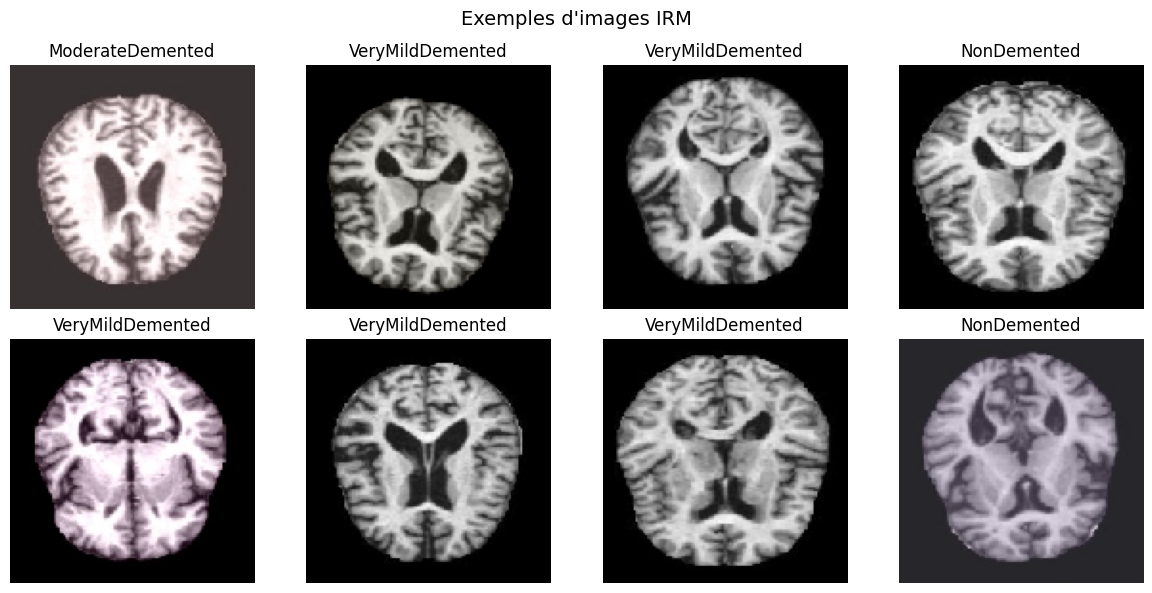

In [ ]:
# Afficher quelques images du dataset
classes = list(train_data.class_indices.keys())
images, labels = next(train_data)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')

plt.suptitle("Exemples d'images IRM", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Construire le modèle CNN
model = Sequential([
    # Bloc 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    # Bloc 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Bloc 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Classificateur
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("✅ Modèle CNN créé !")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

✅ Modèle CNN créé !


In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    verbose=1
)

print("✅ Entraînement terminé !")

Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1127s 1s/step - accuracy: 0.5662 - loss: 0.9180 - val_accuracy: 0.7185 - val_loss: 0.6197
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1139s 1s/step - accuracy: 0.7341 - loss: 0.5947 - val_accuracy: 0.8268 - val_loss: 0.4139
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1118s 1s/step - accuracy: 0.8123 - loss: 0.4369 - val_accuracy: 0.8540 - val_loss: 0.3464
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1090s 1s/step - accuracy: 0.8553 - loss: 0.3367 - val_accuracy: 0.8827 - val_loss: 0.2829
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - accuracy: 0.8872 - loss: 0.2723 - val_accuracy: 0.8891 - val_loss: 0.2751
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1085s 1s/step - accuracy: 0.9094 - loss: 0.2237 - val_accuracy: 0.9044 - val_loss: 0.2320
Epoch 7/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - accuracy: 0.9185 - loss: 0.1952 - val_accuracy: 0.9064 - val_loss: 0.2405
Epoch 8/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 1074s 1s/step - accuracy: 0.9309 - loss: 0.1726 - 

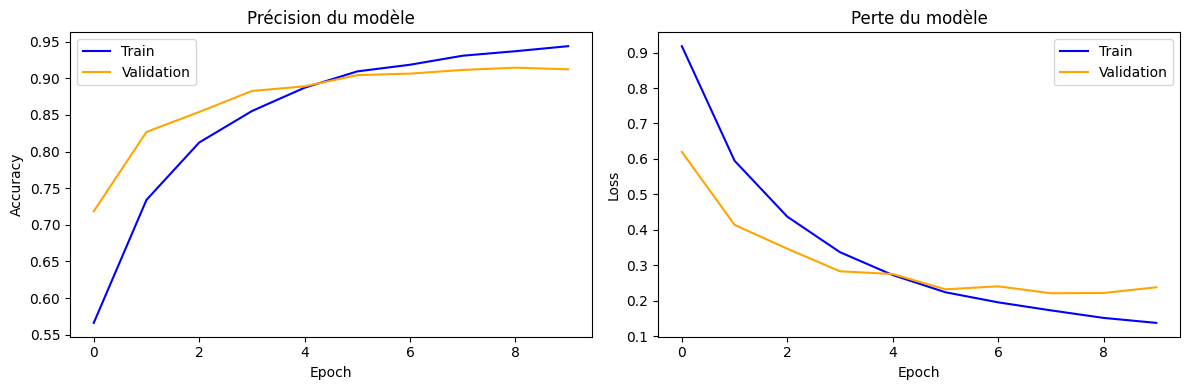

✅ Courbes affichées !


In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation', color='orange')
plt.title('Précision du modèle')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', color='blue')
plt.plot(history.history['val_loss'], label='Validation', color='orange')
plt.title('Perte du modèle')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Courbes affichées !")

Found 33984 images belonging to 4 classes.
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 374s 352ms/step


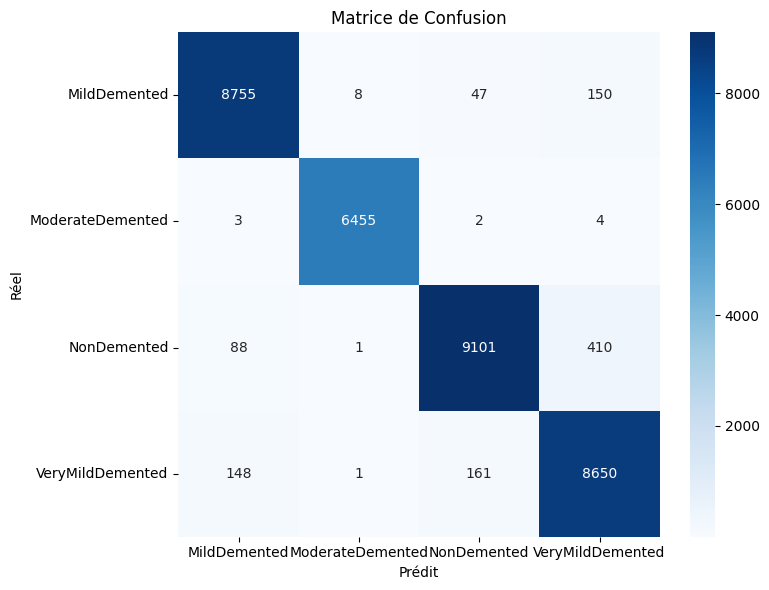

                  precision    recall  f1-score   support

    MildDemented       0.97      0.98      0.98      8960
ModerateDemented       1.00      1.00      1.00      6464
     NonDemented       0.98      0.95      0.96      9600
VeryMildDemented       0.94      0.97      0.95      8960

        accuracy                           0.97     33984
       macro avg       0.97      0.97      0.97     33984
    weighted avg       0.97      0.97      0.97     33984

✅ Évaluation terminée !


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Créer un nouveau générateur de test SANS shuffle
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Prédictions
y_pred = model.predict(test_data, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

# Matrice de confusion
classes = list(test_data.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=classes))
print("✅ Évaluation terminée !")

In [ ]:
# Sauvegarder le modèle
model.save("alzheimer_model.h5")
print("✅ Modèle sauvegardé !")

# Télécharger le modèle sur ton PC
from google.colab import files
files.download("alzheimer_model.h5")
print("✅ Modèle téléchargé sur ton PC !")

In [ ]:
from google.colab import drive
from tensorflow.keras.models import load_model

drive.mount('/content/drive')
model = load_model('/content/drive/MyDrive/alzheimer_model.h5')
print("✅ Drive connecté + Modèle chargé !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


OSError: Unable to synchronously open file (truncated file: eof = 7340032, sblock->base_addr = 0, stored_eof = 26106400)